# Feature engineering and correlation analysis

Explores `data/preprocessed/train` (and test file sizes): loads the same user-level frame as the training pipeline, adds ratio / log / rate features, then studies correlations and univariate scores (MI, F-test, Spearman, χ²) for **churn vs not**, **vol vs invol (among churned)**, and **three-class (not / vol / invol)**, plus multicollinearity and missingness.

**Kernel:** Python from `/home/ansar/work/.venv` (e.g. `Select Kernel` → that interpreter).

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PREPROCESSED = Path("/home/ansar/work/hack-nu-26/data/preprocessed")
TRAIN_DIR = PREPROCESSED / "train"
TEST_DIR = PREPROCESSED / "test"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Build one row per user (same logic as `training_pipeline.ipynb`)

Purchases are joined to transaction attempts on `transaction_id`. Generations are aggregated in chunks.

In [2]:
def load_base_users(data_dir: Path) -> pd.DataFrame:
    u = pd.read_csv(data_dir / "train_users.csv", usecols=["user_id", "churn_status"])
    prop = pd.read_csv(
        data_dir / "train_users_properties.csv",
        usecols=["user_id", "subscription_start_date", "subscription_plan", "country_code"],
    )
    q = pd.read_csv(
        data_dir / "train_users_quizzes.csv",
        usecols=["user_id", "source", "team_size", "experience", "usage_plan", "frustration", "first_feature", "role"],
    )
    df = u.merge(prop, on="user_id", how="left").merge(q, on="user_id", how="left")
    df["subscription_start_ts"] = pd.to_datetime(
        df["subscription_start_date"], utc=True, errors="coerce"
    ).astype("int64")
    df = df.drop(columns=["subscription_start_date"])
    return df


def aggregate_purchases_attempts(data_dir: Path) -> pd.DataFrame:
    pur = pd.read_csv(data_dir / "train_users_purchases.csv", low_memory=False)
    ta = pd.read_csv(data_dir / "train_users_transaction_attempts.csv", low_memory=False)
    for c in ta.columns:
        if c.startswith("is_") or c in {"is_3d_secure", "is_3d_secure_authenticated"}:
            ta[c] = ta[c].map(lambda x: str(x).lower() in {"true", "1"})
    m = pur.merge(ta, on="transaction_id", how="left", suffixes=("_pur", ""))
    bool_cols = [c for c in ta.columns if c.startswith("is_")]
    agg_dict = {
        "transaction_id": "count",
        "purchase_amount_dollars": "sum",
        "purchase_type": "nunique",
        "amount_in_usd": "sum",
    }
    for bc in bool_cols:
        if bc in m.columns:
            agg_dict[bc] = "mean"
    g = m.groupby("user_id", as_index=False).agg(agg_dict)
    rename = {
        "transaction_id": "purch_n",
        "purchase_amount_dollars": "purch_amount_sum",
        "purchase_type": "purch_type_nunique",
        "amount_in_usd": "att_amount_sum",
    }
    g = g.rename(columns=rename)
    for bc in bool_cols:
        if bc in g.columns:
            g = g.rename(columns={bc: f"att_mean_{bc}"})
    return g


def aggregate_generations(data_dir: Path, chunksize: int = 2_000_000) -> pd.DataFrame:
    path = data_dir / "train_users_generations.csv"
    usecols = ["user_id", "status", "generation_type"]
    status_parts: list[pd.Series] = []
    type_parts: list[pd.Series] = []
    for chunk in pd.read_csv(path, chunksize=chunksize, usecols=usecols):
        status_parts.append(chunk.groupby(["user_id", "status"]).size())
        type_parts.append(chunk.groupby(["user_id", "generation_type"]).size())
    st = pd.concat(status_parts).groupby(level=[0, 1]).sum().unstack(fill_value=0)
    st.columns = [f"gen_status_{c}" for c in st.columns.astype(str)]
    gt = pd.concat(type_parts).groupby(level=[0, 1]).sum().unstack(fill_value=0)
    gt.columns = [f"gen_type_{c}" for c in gt.columns.astype(str)]
    out = st.join(gt, how="outer").fillna(0).astype(np.float32)
    out["gen_total"] = out[[c for c in out.columns if c.startswith("gen_status_")]].sum(axis=1)
    return out.reset_index()


def build_user_frame(data_dir: Path) -> tuple[pd.DataFrame, list[str], list[str]]:
    df = load_base_users(data_dir)
    df = df.merge(aggregate_purchases_attempts(data_dir), on="user_id", how="left")
    df = df.merge(aggregate_generations(data_dir), on="user_id", how="left")
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    cat_cols = [c for c in df.columns if c not in num_cols and c not in {"user_id", "churn_status"}]
    for c in cat_cols:
        df[c] = df[c].fillna("skipped").astype(str)
    df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
    df = df.sort_values("subscription_start_ts").reset_index(drop=True)
    return df, num_cols, cat_cols


df, num_cols, cat_cols = build_user_frame(TRAIN_DIR)
print("train users:", len(df), "rows", len(df.columns), "cols")
print("numeric:", len(num_cols), "categorical:", len(cat_cols))

train users: 89484 rows 51 cols
numeric: 40 categorical: 9


In [3]:
df.columns

Index(['user_id', 'churn_status', 'subscription_plan', 'country_code',
       'source', 'team_size', 'experience', 'usage_plan', 'frustration',
       'first_feature', 'role', 'subscription_start_ts', 'purch_n',
       'purch_amount_sum', 'purch_type_nunique', 'att_amount_sum',
       'att_mean_is_3d_secure', 'att_mean_is_3d_secure_authenticated',
       'att_mean_is_prepaid', 'att_mean_is_virtual', 'att_mean_is_business',
       'gen_status_canceled', 'gen_status_completed', 'gen_status_failed',
       'gen_status_in_progress', 'gen_status_nsfw', 'gen_status_queued',
       'gen_status_waiting', 'gen_type_image_model_1',
       'gen_type_image_model_2', 'gen_type_image_model_3',
       'gen_type_image_model_4', 'gen_type_image_model_5',
       'gen_type_image_model_6', 'gen_type_image_model_7',
       'gen_type_image_model_8', 'gen_type_image_model_9',
       'gen_type_video_model_1', 'gen_type_video_model_10',
       'gen_type_video_model_11', 'gen_type_video_model_12',
       'gen_t

## 2. Engineered features

Ratios and logs capture scale; generation completion rate uses status columns when present.

In [4]:
def add_engineered_features(d: pd.DataFrame) -> pd.DataFrame:
    out = d.copy()
    eps = 1e-6

    if {"purch_amount_sum", "purch_n"}.issubset(out.columns):
        out["fe_avg_purchase_amount"] = out["purch_amount_sum"] / (out["purch_n"] + eps)
    if {"att_amount_sum", "purch_amount_sum"}.issubset(out.columns):
        out["fe_att_to_purch_amount_ratio"] = out["att_amount_sum"] / (out["purch_amount_sum"].abs() + eps)
    if {"gen_total", "purch_n"}.issubset(out.columns):
        out["fe_gen_per_purchase"] = out["gen_total"] / (out["purch_n"] + eps)

    for col in ["purch_amount_sum", "att_amount_sum", "gen_total", "purch_n"]:
        if col in out.columns:
            out[f"fe_log1p_{col}"] = np.log1p(out[col].clip(lower=0).fillna(0))

    completed = [c for c in out.columns if c == "gen_status_completed" or str(c).endswith("_completed")]
    if "gen_total" in out.columns and completed:
        num_completed = out[completed].sum(axis=1)
        out["fe_gen_completed_rate"] = num_completed / (out["gen_total"] + eps)

    att_mean_cols = [c for c in out.columns if c.startswith("att_mean_is_")]
    if att_mean_cols:
        out["fe_att_3ds_rate"] = out.get("att_mean_is_3d_secure", pd.Series(np.nan, index=out.index))
        if "att_mean_is_3d_secure_authenticated" in out.columns:
            out["fe_att_3ds_auth_given_3ds"] = out["att_mean_is_3d_secure_authenticated"] / (
                out["att_mean_is_3d_secure"] + eps
            )

    return out


df = add_engineered_features(df)
fe_cols = [c for c in df.columns if c.startswith("fe_")]
print("engineered columns:", fe_cols)

engineered columns: ['fe_avg_purchase_amount', 'fe_att_to_purch_amount_ratio', 'fe_gen_per_purchase', 'fe_log1p_purch_amount_sum', 'fe_log1p_att_amount_sum', 'fe_log1p_gen_total', 'fe_log1p_purch_n', 'fe_gen_completed_rate', 'fe_att_3ds_rate', 'fe_att_3ds_auth_given_3ds']


## 3. Analysis targets (numeric encodings)

Three related prediction tasks:

| Target | Meaning |
|--------|---------|
| **`y_churned`** | **Churn vs not:** 1 if `vol_churn` or `invol_churn`, else 0 (`not_churned`). |
| **`y_vol_if_churned`** | **Vol vs invol (churned users only):** 1 = `vol_churn`, 0 = `invol_churn`; NaN if `not_churned`. |
| **`y_churn_ordinal`** | **Three classes:** 0 = not churned, 1 = vol churn, 2 = invol churn (for multiclass scores). |

Use **`y_churned`** for “will they churn?”; use **`y_vol_if_churned`** on the churned subset for “if they churn, is it voluntary?”; use **`y_churn_ordinal`** for 3-way association (MI / F-test / χ²).

In [5]:
def add_target_encodings(d: pd.DataFrame) -> pd.DataFrame:
    out = d.copy()
    s = out["churn_status"]
    out["y_churned"] = (s != "not_churned").astype(np.float64)
    out["y_vol_if_churned"] = np.where(s != "not_churned", (s == "vol_churn").astype(np.float64), np.nan)
    ordinal = s.map({"not_churned": 0.0, "vol_churn": 1.0, "invol_churn": 2.0})
    out["y_churn_ordinal"] = ordinal.astype(np.float64)
    return out


df = add_target_encodings(df)
df["y_churn_ordinal"].value_counts(dropna=False)

y_churn_ordinal
0.0    44854
2.0    22349
1.0    22281
Name: count, dtype: int64

## 4. Correlations (Pearson)

Uses `numeric_for_corr` (numeric + engineered columns only; categoricals excluded except `subscription_start_ts`).

### 4a. Churn vs not (`y_churned`: 1 = churned, 0 = stayed)

,corr_y_churned
gen_type_video_model_7,0.196179
gen_type_image_model_5,0.120552
gen_type_image_model_7,0.117760
gen_type_video_model_2,0.111957
att_mean_is_business,-0.110682
fe_gen_completed_rate,-0.109238
fe_log1p_purch_amount_sum,0.108201
fe_log1p_att_amount_sum,0.108102
gen_type_video_model_3,0.106842
fe_log1p_purch_n,0.094955


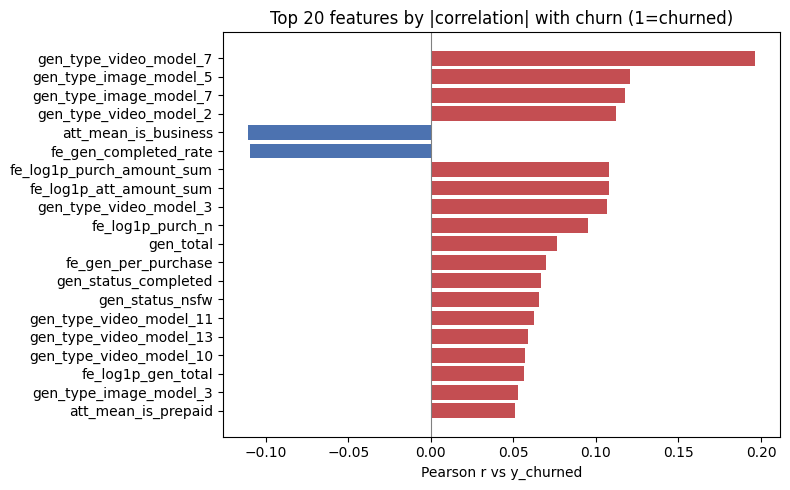

In [6]:
# Exclude targets so they are not duplicated in numeric_for_corr + ["y_churned"] (duplicate cols -> corr()["y_churned"] is a DataFrame).
analysis_exclude = {"user_id", "churn_status", "y_churned", "y_churn_ordinal", "y_vol_if_churned"}
numeric_for_corr = [
    c
    for c in df.columns
    if c not in analysis_exclude and pd.api.types.is_numeric_dtype(df[c])
]

corr_churn = (
    df[numeric_for_corr + ["y_churned"]]
    .corr(numeric_only=True)["y_churned"]
    .drop("y_churned")
    .sort_values(key=np.abs, ascending=False)
)
display(corr_churn.head(25).to_frame("pearson_r__churn_vs_not"))

top_n = 20
top_feats = corr_churn.head(top_n).index.tolist()
fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.25)))
colors = ["#c44e52" if v > 0 else "#4c72b0" for v in corr_churn.head(top_n)]
ax.barh(top_feats[::-1], corr_churn.head(top_n).values[::-1], color=colors[::-1])
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Pearson r vs y_churned (churn=1, stayed=0)")
ax.set_title(f"4a — Top {top_n} |r| with churn vs not")
plt.tight_layout()
plt.show()

### 4b. Vol vs invol among churned (`y_vol_if_churned`: 1 = vol, 0 = invol)

Restricted to users who churned; asks which features align with **voluntary** vs **involuntary** churn.

In [ ]:
sub = df["y_vol_if_churned"].notna()
if sub.sum() > 50:
    corr_vol = (
        df.loc[sub, numeric_for_corr + ["y_vol_if_churned"]]
        .corr(numeric_only=True)["y_vol_if_churned"]
        .drop("y_vol_if_churned")
        .sort_values(key=np.abs, ascending=False)
    )
    display(corr_vol.head(20).to_frame("pearson_r__vol_vs_invol_among_churned"))

    top_nv = 20
    tf = corr_vol.head(top_nv).index.tolist()
    fig, ax = plt.subplots(figsize=(8, max(4, top_nv * 0.25)))
    cols_b = ["#c44e52" if v > 0 else "#4c72b0" for v in corr_vol.head(top_nv)]
    ax.barh(tf[::-1], corr_vol.head(top_nv).values[::-1], color=cols_b[::-1])
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_xlabel("Pearson r vs y_vol_if_churned (vol=1, invol=0)")
    ax.set_title(f"4b — Top {top_nv} |r| with vol vs invol (churned only)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough churned rows for vol-vs-invol correlation.")

## 5. Univariate association (MI, F-test, Spearman, χ²)

Same metrics as before; run for **three targets**:

- **5a — Churn vs not** (`y_churned` binary).
- **5b — Vol vs invol** (`y_vol_if_churned` on churned users only).
- **5c — Three classes** (`y_churn_ordinal`: 0 = not, 1 = vol, 2 = invol): multiclass `f_classif`, `chi2`, and MI. Pearson/Spearman vs an ordinal label are only a rough monotone read; prefer MI/F for this block.

**Pearson** (§4) is linear; **Spearman** is rank-based; **MI** captures nonlinear dependence; **F-test** is between-class separation; **χ²** uses nonnegative shifted features (interpret cautiously on reals).

In [ ]:
def univariate_table(
    frame: pd.DataFrame,
    feature_cols: list[str],
    y: pd.Series,
) -> pd.DataFrame:
    """MI, ANOVA F, chi2 (after per-column shift to nonnegative), Pearson/Spearman vs y."""
    X = frame[feature_cols].to_numpy(dtype=np.float64)
    imp = SimpleImputer(strategy="median")
    X_imp = imp.fit_transform(X)
    y_arr = y.to_numpy()
    if y_arr.dtype != np.int64 and y_arr.dtype != np.int32:
        y_arr = y_arr.astype(np.int64)

    mi = mutual_info_classif(
        X_imp, y_arr, random_state=RANDOM_STATE, n_neighbors=3
    )
    f_scores, f_pvals = f_classif(X_imp, y_arr)
    X_nn = X_imp - X_imp.min(axis=0)
    chi_scores, chi_pvals = chi2(X_nn, y_arr)

    ys = pd.Series(y_arr.astype(float), index=frame.index)
    pear = frame[feature_cols].corrwith(ys, method="pearson")
    spear = frame[feature_cols].corrwith(ys, method="spearman")

    out = pd.DataFrame(
        {
            "feature": feature_cols,
            "pearson_r": pear.values,
            "spearman_r": spear.values,
            "mutual_info": mi,
            "f_classif": f_scores,
            "f_pvalue": f_pvals,
            "chi2": chi_scores,
            "chi2_pvalue": chi_pvals,
        }
    )
    return out.sort_values("mutual_info", ascending=False)


# --- 5a. Churn vs not ---
uni_churn = univariate_table(df, numeric_for_corr, df["y_churned"])
print("5a — Churn vs not (y_churned)")
display(uni_churn.head(30))

fig, ax = plt.subplots(figsize=(8, 7))
top = 25
u = uni_churn.head(top)
ax.barh(u["feature"].iloc[::-1], u["mutual_info"].iloc[::-1], color="#2ca02c")
ax.set_xlabel("Mutual information vs y_churned")
ax.set_title("5a — Top features by MI: churn vs not")
plt.tight_layout()
plt.show()

# --- 5b. Vol vs invol (churned only) ---
sub = df["y_vol_if_churned"].notna()
if sub.sum() > 50:
    uni_vol = univariate_table(
        df.loc[sub].reset_index(drop=True),
        numeric_for_corr,
        df.loc[sub, "y_vol_if_churned"].astype(int).reset_index(drop=True),
    )
    print("5b — Vol vs invol among churned")
    display(uni_vol.head(25))

    fig, ax = plt.subplots(figsize=(8, 6))
    tv = 25
    uv = uni_vol.head(tv)
    ax.barh(uv["feature"].iloc[::-1], uv["mutual_info"].iloc[::-1], color="#9467bd")
    ax.set_xlabel("Mutual information vs y_vol_if_churned")
    ax.set_title("5b — Top features by MI: vol vs invol (churned only)")
    plt.tight_layout()
    plt.show()
else:
    print("5b skipped: not enough churned rows for vol vs invol.")
    uni_vol = None

# --- 5c. Three classes: not / vol / invol ---
uni_3 = univariate_table(df, numeric_for_corr, df["y_churn_ordinal"].astype(int))
print("5c — Three classes: not=0, vol=1, invol=2")
display(uni_3.head(30))

fig, ax = plt.subplots(figsize=(8, 7))
top3 = 25
u3 = uni_3.head(top3)
ax.barh(u3["feature"].iloc[::-1], u3["mutual_info"].iloc[::-1], color="#ff7f0e")
ax.set_xlabel("Mutual information vs y_churn_ordinal (3 classes)")
ax.set_title("5c — Top features by MI: not vs vol vs invol")
plt.tight_layout()
plt.show()


## 6. Correlation heatmap (numeric subset)

If there are many columns, the heatmap uses the union of: target-related top features, all `fe_*` columns, and high-variance numerics (capped).

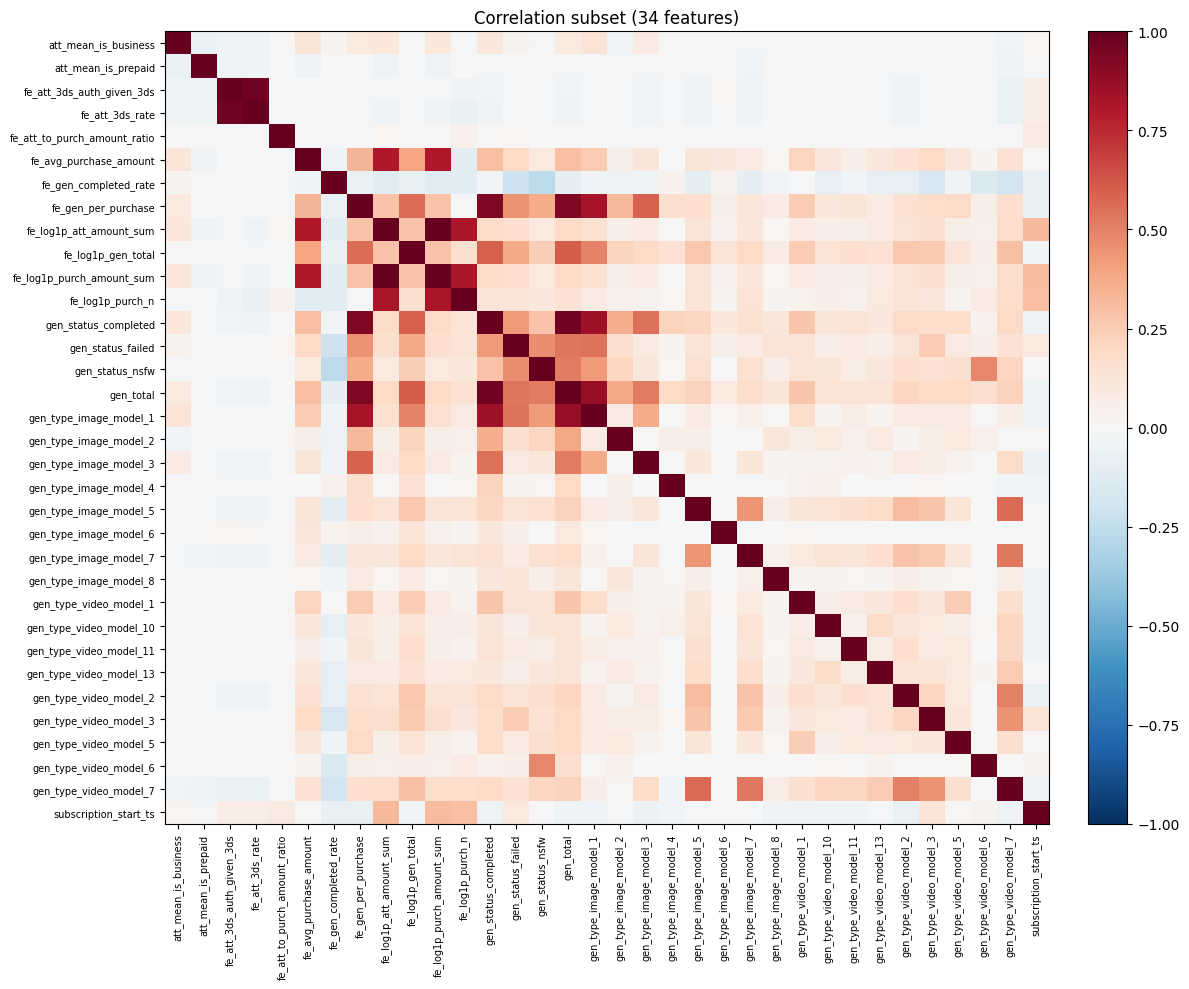

In [8]:
def correlation_heatmap(corr: pd.DataFrame, title: str, figsize=(14, 12)) -> None:
    m = corr.values
    labels = corr.columns.tolist()
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(m, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


num_only = [c for c in numeric_for_corr if c != "y_churned"]
full = df[num_only].corr(numeric_only=True)
max_cols = 45
if len(num_only) <= max_cols:
    correlation_heatmap(full, "Numeric feature correlation matrix")
else:
    by_target = corr_churn.head(25).index.tolist()
    fe_set = [c for c in num_only if c.startswith("fe_")]
    var_rank = df[num_only].var(numeric_only=True).sort_values(ascending=False).head(15).index.tolist()
    heat_cols = sorted(set(by_target) | set(fe_set) | set(var_rank))
    heat_cols = [c for c in heat_cols if c in full.columns][:max_cols]
    sub_corr = full.loc[heat_cols, heat_cols]
    correlation_heatmap(sub_corr, f"Correlation subset ({len(heat_cols)} features)", figsize=(12, 10))

## 7. Highly correlated pairs (multicollinearity)

Pairs with $|r| \geq 0.9$ (excluding diagonal) are candidates for dropping one feature or using regularization.

In [9]:
def high_corr_pairs(corr: pd.DataFrame, thresh: float = 0.9) -> pd.DataFrame:
    cols = corr.columns
    pairs = []
    for i, a in enumerate(cols):
        for j in range(i + 1, len(cols)):
            b = cols[j]
            v = corr.iloc[i, j]
            if np.isfinite(v) and abs(v) >= thresh:
                pairs.append((a, b, float(v)))
    out = pd.DataFrame(pairs, columns=["feature_a", "feature_b", "corr"])
    return out.sort_values("corr", key=np.abs, ascending=False)


pairs = high_corr_pairs(full, thresh=0.9)
print("pairs with |r| >= 0.9:", len(pairs))
display(pairs.head(40))

pairs with |r| >= 0.9: 12


,feature_a,feature_b,corr
3,att_mean_is_3d_secure,fe_att_3ds_rate,1.000000
10,fe_log1p_purch_amount_sum,fe_log1p_att_amount_sum,0.999967
0,purch_amount_sum,att_amount_sum,0.999559
5,att_mean_is_3d_secure_authenticated,fe_att_3ds_rate,0.991390
2,att_mean_is_3d_secure,att_mean_is_3d_secure_authenticated,0.991390
6,att_mean_is_3d_secure_authenticated,fe_att_3ds_auth_given_3ds,0.984520
11,fe_att_3ds_rate,fe_att_3ds_auth_given_3ds,0.975983
4,att_mean_is_3d_secure,fe_att_3ds_auth_given_3ds,0.975983
7,gen_status_completed,gen_total,0.967684
8,gen_status_completed,fe_gen_per_purchase,0.931822


## 8. Missing values (numeric)

Share of missing / NaN / inf per column after merges.

In [10]:
miss = []
for c in df.columns:
    if c in {"user_id", "churn_status"}:
        continue
    s = df[c]
    if pd.api.types.is_numeric_dtype(s):
        pct = float(s.isna().mean())
    else:
        pct = float(s.isna().mean())
    miss.append((c, pct))
miss_df = pd.DataFrame(miss, columns=["column", "frac_missing"]).sort_values("frac_missing", ascending=False)
display(miss_df.head(25))
print("columns with >5% missing:", (miss_df["frac_missing"] > 0.05).sum())

,column,frac_missing
60,y_vol_if_churned,0.501252
51,fe_gen_per_purchase,0.184391
10,purch_n,0.143154
11,purch_amount_sum,0.143154
12,purch_type_nunique,0.143154
13,att_amount_sum,0.143154
17,att_mean_is_virtual,0.143154
16,att_mean_is_prepaid,0.143154
18,att_mean_is_business,0.143154
58,fe_att_3ds_auth_given_3ds,0.143154


columns with >5% missing: 15


## 9. Categorical cardinality (train)

Useful for choosing hashing, high-cardinality encoders, or grouping rare levels.

In [11]:
cat_info = []
for c in cat_cols:
    cat_info.append({"column": c, "n_unique": df[c].nunique(), "dtype": str(df[c].dtype)})
cat_df = pd.DataFrame(cat_info).sort_values("n_unique", ascending=False)
display(cat_df)

,column,n_unique,dtype
2,source,527,str
1,country_code,152,str
7,first_feature,12,str
8,role,11,str
6,frustration,7,str
5,usage_plan,7,str
3,team_size,7,str
4,experience,5,str
0,subscription_plan,4,str


## 10. Preprocessed file layout

Train vs test row counts from CSVs (quick sanity check).

In [12]:
def count_lines(path: Path) -> int:
    with path.open("rb") as f:
        return sum(1 for _ in f) - 1


rows = []
for split, d in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    for p in sorted(d.glob("*.csv")):
        rows.append({"split": split, "file": p.name, "n_rows": count_lines(p)})
files_df = pd.DataFrame(rows)
display(files_df)

,split,file,n_rows
0,train,train_users.csv,89480
1,train,train_users_generations.csv,28315752
2,train,train_users_properties.csv,89480
3,train,train_users_purchases.csv,95747
4,train,train_users_quizzes.csv,89484
5,train,train_users_transaction_attempts.csv,95747
6,test,test_users.csv,7000
7,test,test_users_generations.csv,1078213
8,test,test_users_properties.csv,7000
9,test,test_users_purchases.csv,8825


## 11. Optional: export engineered train frame

Uncomment to write a parquet or CSV for modeling experiments.

In [13]:
# out_path = PREPROCESSED / "train_user_level_engineered.parquet"
# df.drop(columns=["y_churned", "y_vol_if_churned", "y_churn_ordinal"], errors="ignore").to_parquet(out_path, index=False)
# print("wrote", out_path)

## 12. Selected features (MI / correlation / collinearity)

Runs `feature_selection.py`. Metadata: `thresholds.json`, `univariate_train_y_churned.csv`, `dropped_features.csv`, `feature_manifest.json`.

**`data/feature_engineering/train/`** and **`data/feature_engineering/test/`** mirror **`preprocessed/train/`** and **`preprocessed/test/`**: `*_users.csv`, `*_users_properties.csv` (preprocessed dates/plan/country + `subscription_start_ts`), `*_users_quizzes.csv`, `*_users_selected_numerics.csv`, and copies of purchases / attempts / generations (use `--no-copy-raw` to skip large files). Test uses the **same** selected numeric columns as train (missing `gen_type_*` etc. are filled with NaN). Use `--no-test-tables` to skip `test/`. Add `--wide-csv` for `train_user_level_selected.csv` and `test_user_level_selected.csv` at the feature_engineering root.

**Default gates:** drop numeric column if `mutual_info < 0.015` **or** `|Pearson vs y_churned| < 0.07` (optional Spearman / F / χ² gates). Prune pairs with `|r| ≥ 0.92` (keep higher MI; `subscription_start_ts` protected).

In [ ]:
import subprocess
import sys
from pathlib import Path

ROOT = Path("/home/ansar/work/hack-nu-26")
subprocess.run([sys.executable, str(ROOT / "feature_selection.py")], cwd=ROOT, check=True)
print("Done — see", ROOT / "data" / "feature_engineering")